# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import os
import pandas as pd
import matplotlib.colors as mcolors

from helpers import create_r_style_plot, fit_mixed_glm, stat_tests_mixed_glm, add_hypothesis
import popy.config as cfg
from popy.config import PROJECT_PATH_LOCAL as PATH
from popy.config import COLORS as COLORS

PATH = cfg.PROJECT_PATH_LOCAL


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-j8jatul8 because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
##% Plotting Functions

# fontsize = 8
plt.rcParams.update({'font.size': 8})

def plot_RL_vs_forage_single_sess_horizontal(ax=None, data=None, x_col=None, y_col=None, title=None, session_col='session', paper_format=False):
    """Create R-style plot with box and jittered points (horizontal version)
    
    Args:
        ax: matplotlib axis
        data: DataFrame with the data
        x_col: column name for x-axis categories (now on y-axis)
        y_col: column name for values (now on x-axis)
        title: plot title
        session_col: column name for session identifier
    """
    palette = COLORS
    axis = ax
    if paper_format:
        fontsize = 8
        h = 2 
        w = 2
        s = 15
    else:
        fontsize = 18

        h = 3
        w = 4
        s = 10

    if axis is None:
        fig, ax = plt.subplots(1, 1, figsize=(w, h))

    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    y_positions = [0, .5]
    
    x_offset = .4
    lw = .4 
        
    # Create boxplots (horizontal)
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=y_positions, widths=0.5, patch_artist=True,
                    boxprops=dict(alpha=0.7),
                    showfliers=False,
                    medianprops=dict(color='black'),
                    flierprops=dict(markersize=3, alpha=0.5),
                    vert=False)  # <-- horizontal

    # Color the boxes
    colors = [palette[cat] for cat in categories]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    # Store jitter positions
    jitter_positions = {}
    # If color is a string like 'red' or hex '#ff0000'
    base_rgba = mcolors.to_rgba(color, alpha=.5)
    # Darken by mixing with black (multiply RGB values by 0.7 to make it darker)
    edge_color = (base_rgba[0] * 0.7, base_rgba[1] * 0.7, base_rgba[2] * 0.7, 1.0)

    # Add jittered points (horizontal scatter)
    for i, cat in enumerate(categories):
        x_data = data.loc[data[x_col] == cat, y_col].values
        # If color is a string like 'red' or hex '#ff0000'
        base_rgba = mcolors.to_rgba(palette[cat], alpha=.5)
        # Darken by mixing with black (multiply RGB values by 0.7 to make it darker)
        edge_color = (base_rgba[0] * 0.7, base_rgba[1] * 0.7, base_rgba[2] * 0.7, 1.0)
        y_jitter = np.random.normal(-1, 0.15, size=len(x_data))
        
        # Generate random zorder values for each point
        zorder_values = np.random.uniform(10, 1000, size=len(x_data))
        
        # Plot each point individually with its own random zorder
        for x_val, y_val, z_val in zip(x_data, y_jitter, zorder_values):
            scatter = ax.scatter(x_val, y_val, s=s, facecolors=base_rgba, edgecolors=edge_color, linewidth=.5, zorder=z_val)

        if session_col is not None:
            session_data = data.loc[data[x_col] == cat, session_col].values
            jitter_positions[cat] = dict(zip(session_data, zip(x_data, y_jitter)))

    # Significance test
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        _, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        # Calculate mean positions for significance line
        mean1 = group1_data.mean()
        mean2 = group2_data.mean()
        
        # Get y positions for the categories
        y1 = y_positions[0]
        y2 = y_positions[1]
        
        # Position significance line above the plots
        line_height = max(y_positions) + 0.8
        
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'

        # Add horizontal significance line spanning between box means
        ax.plot([mean1, mean2], [line_height, line_height], '-k', lw=2*lw)
        # Add vertical lines connecting to boxes
        ax.plot([mean1, mean1], [line_height - 0.1, line_height], '-k', lw=2*lw)
        ax.plot([mean2, mean2], [line_height - 0.1, line_height], '-k', lw=2*lw)
        # Add significance text at the center
        ax.text((mean1 + mean2) / 2, line_height + 0.05, f'{significance} (n={len(group1_data)})',
                va='bottom', ha='center', fontsize=fontsize)

    # Formatting
    ax.axhline(-1, linestyle='-', alpha=1, color='black', lw=4*lw, zorder=1)

    vline_bottom = min(y_positions) - 1
    vline_top = max(y_positions) + 0.5  # stay below significance line
    ax.vlines(0, vline_bottom, vline_top, linestyle='-', color='black', lw=1, zorder=0)

    ax.set_yticks([])
    ax.set_xlabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$', fontsize=fontsize)
    ax.tick_params(axis='x', length=0)  # Remove x tick markers, keep labels

    ax.set_ylabel('')

    ax.set_title(title, fontsize=fontsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)

    if axis is None:
        return fig, ax
    else:
        return ax

def print_stats(stats_summary):
    # list of hypotheses in order
    ordered_hypotheses = ['Foraging', 'Standard RL', 'Inferential RL', 'none']


    ## print stats in user-friendly format
    for (monkey, subregion), group in stats_summary.groupby(['monkey', 'subregion']):
        print(f"{monkey} - {subregion}:")
        n_sessions = group['count'].sum()
        for _, row in group.iterrows():
            print(f"  {row['hypothesis']}: {row['count']} sessions ({row['count'] / n_sessions * 100:.1f}%)")
        print()  # Add a newline for better readability



    # now plot donut charts for each monkey and sessions

    fig2, axs = plt.subplots(1, 3, figsize=(5, 2))
    plt.rcParams.update({'font.size': 8})

    subregions = stats_summary['subregion'].unique()

    for s, subregion in enumerate(subregions):
        group = stats_summary[stats_summary['subregion'] == subregion]
        # sum count per monkey
        group = group.groupby('hypothesis').sum().reset_index()

        # order hypotheses as ['Foraging', 'Standard RL', 'Inferential RL', 'PROBLEM', 'none']
        group = group.copy()  # Create a copy to avoid SettingWithCopyWarning
        group['hypothesis'] = pd.Categorical(group['hypothesis'], categories=ordered_hypotheses, ordered=True)
        group = group.sort_values('hypothesis')

        ax = axs[s]

        if not group.empty:
            # Get colors for each hypothesis
            colors = [COLORS[hypothesis] for hypothesis in group['hypothesis']]
            
            # Create donut chart with better percentage positioning
            wedges, texts, autotexts = ax.pie(group['count'], 
                                            labels=None,  # Remove labels from chart
                                            colors=colors,
                                            autopct='%1.1f%%',
                                            startangle=90,
                                            counterclock=False,
                                            pctdistance=1,  # Position percentages closer to edge
                                            wedgeprops=dict(alpha=.6, width=0.5))  # This creates the donut hole

            # Improve percentage text formatting
            for autotext in autotexts:
                autotext.set_color('black')
                autotext.set_fontsize(7)
                #autotext.set_weight('bold')
                autotext.set_bbox(dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8, edgecolor='none'))

            # Add center circle for better donut appearance
            centre_circle = plt.Circle((0,0), 0.50, fc='white', edgecolor=COLORS[subregion], linewidth=2)
            ax.add_artist(centre_circle)
            # Add circle around (edge)
            centre_circle = plt.Circle((0,0), 1, fc='none', edgecolor=COLORS[subregion], linewidth=2)
            ax.add_artist(centre_circle)

            # Add title in the center
            ax.text(0, 0, f'{subregion}', ha='center', va='center', 
                    fontsize=8, weight='bold', color=COLORS[subregion])

            ax.set_title(f'KA & PO, n={group["count"].sum()}', fontsize=8, pad=10)
            
        else:
            # Hide subplot if no data
            ax.set_visible(False)


    fig1, axs = plt.subplots(2, 3, figsize=(5, 4), 
                            gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.1, 'wspace': 0.2})
    plt.rcParams.update({'font.size': 8})

    subregions = stats_summary['subregion'].unique()
    monkeys = stats_summary['monkey'].unique()

    for s, subregion in enumerate(subregions):
        for m, monkey in enumerate(monkeys):
            group = stats_summary[(stats_summary['subregion'] == subregion) & 
                                  (stats_summary['monkey'] == monkey)]
            # sum count per monkey
            group = group.groupby('hypothesis').sum().reset_index()

            # order hypotheses as ['Foraging', 'Standard RL', 'Inferential RL', 'PROBLEM', 'none']
            group = group.copy()  # Create a copy to avoid SettingWithCopyWarning
            group['hypothesis'] = pd.Categorical(group['hypothesis'], categories=ordered_hypotheses, ordered=True)
            group = group.sort_values('hypothesis')

            ax = axs[m, s]

            if not group.empty:
                # Get colors for each hypothesis
                colors = [COLORS[hypothesis] for hypothesis in group['hypothesis']]
                
                # Create donut chart with better percentage positioning
                wedges, texts, autotexts = ax.pie(group['count'], 
                                                labels=None,  # Remove labels from chart
                                                colors=colors,
                                                autopct='%1.1f%%',
                                                startangle=90,
                                                counterclock=False,
                                                pctdistance=1,  # Position percentages closer to edge
                                                wedgeprops=dict(alpha=.6, width=0.5))  # This creates the donut hole

                # Improve percentage text formatting
                for autotext in autotexts:
                    autotext.set_color('black')
                    autotext.set_fontsize(7)
                    #autotext.set_weight('bold')
                    autotext.set_bbox(dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.8, edgecolor='none'))

                # Add center circle for better donut appearance
                centre_circle = plt.Circle((0,0), 0.50, fc='white', edgecolor=COLORS[subregion], linewidth=2)
                ax.add_artist(centre_circle)
                # Add circle around (edge)
                centre_circle = plt.Circle((0,0), 1, fc='none', edgecolor=COLORS[subregion], linewidth=2)
                ax.add_artist(centre_circle)

                # Add title in the center
                ax.text(0, 0, f'{subregion}', ha='center', va='center', 
                        fontsize=8, weight='bold', color=COLORS[subregion])

                ax.set_title(f'{monkey}, n={group["count"].sum()}', fontsize=8, pad=10)

            else:
                # Hide subplot if no data
                ax.set_visible(False)
    
    # Create legend using all possible hypotheses
    legend_colors = [COLORS[hypothesis] for hypothesis in ordered_hypotheses]
    legend_handles = [plt.Rectangle((0,0),1,1, facecolor=color) for color in legend_colors]
    
    # Add legend to the figure
    fig1.legend(legend_handles, ordered_hypotheses, loc='center left', bbox_to_anchor=(1, 0.5))
    fig2.legend(legend_handles, ordered_hypotheses, loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.tight_layout()  # Re-enabled tight_layout for better spacing
    return fig1, fig2

def plot_session_wise(results_df_mean, monkeys='two'):
    # Create the figure
    # Create the plots
    plt.rcParams.update({'font.size': 8})

    subregions = results_df_mean['subregion'].unique()
    n_subregions = len(subregions)
    
    if monkeys == 'both':
        # 1x3 grid (or 1xN for N subregions)
        n_rows, n_cols = 1, n_subregions
        fig = plt.figure(figsize=(3 * n_cols, 2))
        
        # Create main grid
        gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig)
        
        axs = []
        
        for s, subregion in enumerate(subregions):
            group = results_df_mean[results_df_mean['subregion'] == subregion]
            
            # Create subdivided grid for this subplot
            gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, gs_main[0, s], 
                                                     wspace=0.1, hspace=0.1)
            
            # Create the two sub-axes
            ax1 = fig.add_subplot(gs_sub[0, 0])
            ax2 = fig.add_subplot(gs_sub[0, 1], sharey=ax1)
            
            # Within target plot
            create_r_style_plot(ax1, 
                            group.loc[group['type'] == 'within'], 
                            'feedback', 'dV_neural', 'Within target')
            
            # Alter target plot  
            create_r_style_plot(ax2, 
                            group.loc[group['type'] == 'alter'], 
                            'feedback', 'dV_neural', 'Alter target')
            
            # remove y axis, ticks and labels from 2nd plot
            ax2.yaxis.set_visible(False)
            # Add title for this subregion
            ax1.set_title(f'{subregion}', fontsize=8)
            ax2.set_title(f'{subregion}', fontsize=8)
            axs.append([ax1, ax2])
    
    else:
        # 2x3 grid (or 2xN for N subregions)
        monkeys_list = results_df_mean['monkey'].unique()
        n_monkeys = len(monkeys_list)
        n_rows, n_cols = n_monkeys, n_subregions
        
        fig = plt.figure(figsize=(5 * n_cols, 3 * n_rows))
        
        # Create main grid
        gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig)
        
        axs = []
        
        for m, monkey in enumerate(monkeys_list):
            row_axs = []
            for s, subregion in enumerate(subregions):
                group = results_df_mean[(results_df_mean['monkey'] == monkey) & 
                                      (results_df_mean['subregion'] == subregion)]
                
                # Create subdivided grid for this subplot
                gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, gs_main[m, s], 
                                                         wspace=0.1, hspace=0.1)
                
                # Create the two sub-axes
                ax1 = fig.add_subplot(gs_sub[0, 0])
                ax2 = fig.add_subplot(gs_sub[0, 1], sharey=ax1)
                
                # Within target plot
                create_r_style_plot(ax1, 
                                group.loc[group['type'] == 'within'], 
                                'feedback', 'dV_neural', 'Within target')
                
                # Alter target plot
                create_r_style_plot(ax2, 
                                group.loc[group['type'] == 'alter'], 
                                'feedback', 'dV_neural', 'Alter target')
                
                # Add title for this subplot
                #gs_sub.suptitle(f'{monkey} - {subregion}', fontsize=12, y=0.98)
                
                row_axs.append([ax1, ax2])
            axs.append(row_axs)

    return fig, axs 

def create_2d_scatter_with_marginals(data, x_type='within', y_type='alter', 
                                   session_col='session', feedback_col='feedback',
                                   value_col='dV_neural', title=None, palette=None,
                                paper_format=False):
    """
    Create a 2D scatter plot with marginal distributions
    
    Args:
        data: DataFrame with the data
        x_type: type value for x-axis (e.g., 'within')
        y_type: type value for y-axis (e.g., 'alter')
        session_col: column name for session identifier
        feedback_col: column name for feedback (0/1)
        value_col: column name for the neural values
        title: plot title
        palette: color palette dict
        figsize: figure size
        paper_format: whether to use paper formatting
    """
    
    if palette is None:
        palette = {'0': 'tab:red', '1': 'tab:green'}
    
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        s = 15
        h = 2.5 * 5.3/6
        w = 2.5 * 5.3/6
        lw = 0.4
    else:
        plt.rcParams.update({'font.size': 12})
        s = 30
        lw = 0.8
        h, w = 6, 6

    # Trick: if signif is not a column, add all trues
    if 'dV_signif' not in data.columns:
        data['dV_signif'] = True

    # Prepare data for scatter plot
    # Get x-axis data (e.g., within target)
    x_data = data[data['type'] == x_type].copy()
    # Get y-axis data (e.g., alter target) 
    y_data = data[data['type'] == y_type].copy()
    
    # Create scatter data by merging on session and feedback
    scatter_data = []
    
    count_all, count_within_signif, count_within_alter_signif = 0, 0, 0
    for session in data[session_col].unique():
        count_all += 1
        signif_same = x_data[(x_data[session_col] == session) & (x_data[feedback_col] == 1)]['dV_signif'].values[0]
        signif_alter = y_data[(y_data[session_col] == session) & (y_data[feedback_col] == 1)]['dV_signif'].values[0]
        value_coding = data[data['session'] == session]['value_coding'].values[0]
        for feedback in data[feedback_col].unique():
            x_val = x_data[(x_data[session_col] == session) & 
                          (x_data[feedback_col] == feedback)][value_col].values
            y_val = y_data[(y_data[session_col] == session) & 
                          (y_data[feedback_col] == feedback)][value_col].values
            
            if len(x_val) > 0 and len(y_val) > 0:
                scatter_data.append({
                    'x': x_val[0],
                    'y': y_val[0], 
                    'feedback': str(feedback),
                    'session': session,
                    'signif_same': signif_same,
                    'signif_alter': signif_alter,
                    'value_coding': value_coding
                })
    
    scatter_df = pd.DataFrame(scatter_data)

    # Create figure with gridspec for marginal plots
    fig = plt.figure(figsize=(w, h))
    
    # Define the grid: main plot, top histogram, right histogram
    gs = fig.add_gridspec(3, 3, 
                         width_ratios=[1, 4, 1], 
                         height_ratios=[1, 4, 1],
                         hspace=0.05, wspace=0.05)
    
    # Main scatter plot
    ax_main = fig.add_subplot(gs[1, 1])
    
    # Marginal plots
    ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
    
    # Create scatter plot
    for feedback in ['0', '1']:
        for signif_same in [True, False]:
            for signif_alter in [True, False]:
                # Filter data for this feedback and significance (only delta consistent sessions)
                mask = (scatter_df['feedback'] == feedback) & \
                       (scatter_df['signif_same'] == signif_same) & \
                       (scatter_df['signif_alter'] == signif_alter) & \
                       (scatter_df['value_coding'] == 'Delta rule (loose)')
                
                if mask.sum() > 0:
                    if signif_same is False:
                        ax_main.scatter(scatter_df.loc[mask, 'x'], 
                                   scatter_df.loc[mask, 'y'],
                                   c='black',
                                   alpha=0.3, 
                                   linewidths=lw*2,
                                   s=s/2,
                                   marker='x',
                                   zorder=0,
                                   )
                    else:
                        ax_main.scatter(scatter_df.loc[mask, 'x'], 
                                   scatter_df.loc[mask, 'y'],
                                   c=palette[feedback] if signif_alter else 'white',
                                   alpha=0.7, 
                                   s=s,
                                   edgecolor='black' if signif_alter else palette[feedback], 
                                   linewidth=lw,
                                   label=f'{"Unrewarded" if feedback == "0" else "Rewarded"}',
                                   zorder=10)
                        
                # set an x for those that are not delta consistent
                mask = (scatter_df['feedback'] == feedback) & \
                       (scatter_df['signif_same'] == signif_same) & \
                       (scatter_df['signif_alter'] == signif_alter) & \
                       (scatter_df['value_coding'] != 'Delta rule (loose)')
                
                if mask.sum() > 0:
                    ax_main.scatter(scatter_df.loc[mask, 'x'], 
                                scatter_df.loc[mask, 'y'],
                                c='black',
                                alpha=0.3, 
                                linewidths=lw*2,
                                s=s/2,
                                marker='x',
                                zorder=0,
                                )
        
    
    # Add connecting lines between paired points (same session)
    if session_col == 'session':
        for session in scatter_df['session'].unique():
            session_data = scatter_df[scatter_df['session'] == session]
            if len(session_data) == 2:  # Both feedback conditions present
                x_vals = session_data['x'].values
                y_vals = session_data['y'].values
                ax_main.plot(x_vals, y_vals, '-', color='gray', alpha=0.3, 
                            linewidth=lw, zorder=0)
    
    # Add diagonal reference line
    lims = [
        np.min([ax_main.get_xlim(), ax_main.get_ylim()]),
        np.max([ax_main.get_xlim(), ax_main.get_ylim()]),
    ]
    ax_main.plot(lims, lims, 'k--', alpha=0.5, zorder=0, linewidth=lw)
    
    # Add zero lines
    ax_main.axhline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    ax_main.axvline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    
    # Set labels
    ax_main.set_xlabel(f'Within-target change\nin neural value')
    ax_main.set_ylabel(f'Across-target change\nin neural value')
    #ax_main.legend(frameon=False)
    
    # Create marginal distributions (top - x-axis distribution)
    for fb_id, feedback in enumerate(['0', '1']):
        # X-axis marginal (top)
        x_feedback_data = x_data[x_data[feedback_col] == int(feedback)][value_col].values
        if len(x_feedback_data) > 0:
            # Violin plot
            density = stats.gaussian_kde(x_feedback_data)
            x_range = np.linspace(x_feedback_data.min() - 0.1 * np.ptp(x_feedback_data),
                                 x_feedback_data.max() + 0.1 * np.ptp(x_feedback_data), 200)
            density_values = density(x_range)
            density_values = density_values / density_values.max() * 0.8
            
            ax_top.fill_between(x_range, 0, density_values, 
                               color=palette[feedback], alpha=0.3, 
                               edgecolor='black', linewidth=lw)
            
            # Box plot
            bp = ax_top.boxplot([x_feedback_data], positions=[0.4-fb_id*.2], widths=0.2, 
                               patch_artist=True, vert=False,
                               boxprops=dict(alpha=0.7, facecolor=palette[feedback]),
                               showfliers=False, medianprops=dict(color='black'))
    
    # Calculate significance for X-axis marginal
    x_data_pos = x_data[x_data['feedback'] == 1][value_col].values
    x_data_neg = x_data[x_data['feedback'] == 0][value_col].values
    U_x, p_value_x = stats.mannwhitneyu(x_data_pos, x_data_neg, alternative='two-sided')
    
    # Add significance line and p-value for X-axis marginal (top)
    # Position line between the box plot centers
    x_pos_center = np.median(x_data_pos)  # Center of positive feedback data
    x_neg_center = np.median(x_data_neg)  # Center of negative feedback data
    y_line = 0.9  # Position of the line
    line_height = 0.05  # Height of the brackets
    
    # Draw horizontal line between the medians
    ax_top.plot([x_neg_center, x_pos_center], [y_line, y_line], 'k-', linewidth=lw)
    
    # Format p-value with significance stars and sample size
    n_total = len(x_data_pos) + len(x_data_neg)
    if p_value_x > 0.05:
        p_text_x = f'n.s.'
    elif p_value_x <= 0.001:
        p_text_x = f'***'
    elif p_value_x <= 0.01:
        p_text_x = f'**'
    elif p_value_x <= 0.05:
        p_text_x = f'*'
    
    ax_top.text((x_neg_center + x_pos_center) / 2, y_line * 1.1, p_text_x, 
                ha='center', va='bottom', fontsize=plt.rcParams['font.size']-1)

    # Y-axis marginal (right)
    for fb_id, feedback in enumerate(['0', '1']):
        y_feedback_data = y_data[y_data[feedback_col] == int(feedback)][value_col].values
        if len(y_feedback_data) > 0:
            # Violin plot
            density = stats.gaussian_kde(y_feedback_data)
            y_range = np.linspace(y_feedback_data.min() - 0.1 * np.ptp(y_feedback_data),
                                 y_feedback_data.max() + 0.1 * np.ptp(y_feedback_data), 200)
            density_values = density(y_range)
            density_values = density_values / density_values.max() * 0.8
            
            ax_right.fill_betweenx(y_range, 0, density_values, 
                                  color=palette[feedback], alpha=0.3, 
                                  edgecolor='black', linewidth=lw)
            
            # Box plot
            bp = ax_right.boxplot([y_feedback_data], positions=[0.4-fb_id*.2], widths=0.2, 
                                 patch_artist=True, vert=True,
                                 boxprops=dict(alpha=0.7, facecolor=palette[feedback]),
                                 showfliers=False, medianprops=dict(color='black'))
    
    # Calculate significance for Y-axis marginal
    y_data_pos = y_data[y_data['feedback'] == 1][value_col].values
    y_data_neg = y_data[y_data['feedback'] == 0][value_col].values
    U_y, p_value_y = stats.mannwhitneyu(y_data_pos, y_data_neg, alternative='two-sided')

    # Add significance line and p-value for Y-axis marginal (right)
    # Position line between the box plot centers
    y_pos_center = np.median(y_data_pos)  # Center of positive feedback data
    y_neg_center = np.median(y_data_neg)  # Center of negative feedback data
    x_line = 0.9  # Position of the line
    line_width = 0.05  # Width of the brackets
    
    # Draw vertical line between the medians
    ax_right.plot([x_line, x_line], [y_neg_center, y_pos_center], 'k-', linewidth=lw)
    
    # Format p-value with significance stars and sample size
    if p_value_y > 0.05:
        p_text_y = f'n.s.'
    elif p_value_y <= 0.001:
        p_text_y = f'***'
    elif p_value_y <= 0.01:
        p_text_y = f'**'
    elif p_value_y <= 0.05:
        p_text_y = f'*'
    
    ax_right.text(x_line*1.3, (y_neg_center + y_pos_center) / 2, p_text_y, 
                  ha='center', va='center', rotation=90, fontsize=plt.rcParams['font.size']-1)
    
    # Add zero lines to marginal plots
    ax_top.axvline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    ax_right.axhline(0, linestyle='--', alpha=0.5, color='black', linewidth=lw, zorder=0)
    
    # Format marginal plots
    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.set_ylim(0, 1)
    ax_top.set_yticks([])
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['left'].set_visible(False)
    ax_top.tick_params(labelbottom=False)
    
    ax_right.set_ylim(ax_main.get_ylim())
    ax_right.set_xlim(0, 1)
    ax_right.set_xticks([])
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['bottom'].set_visible(False)
    ax_right.tick_params(labelleft=False)
    
    # Format main plot
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    
    n_total = len(np.unique(x_data['session']))  # Number of unique sessions
    plt.suptitle(f'n= {n_total}')

    return fig, ax_main, ax_top, ax_right


In [3]:
def plot_stats_detailed(stats_df, time_window):
    # plot mean stats across monkeys
    stats_df_sum = stats_df.groupby(['subregion', 'hypothesis'])['count'].sum().reset_index()

    order = ['Foraging', 'Inferential RL', 'Standard RL', 'Feedback coding', 'none', 'PROBLEM']

    fig, axs = plt.subplots(1, 3, figsize=(10, 2.5), sharey=True)
    plt.suptitle(f'time: {time_window}', fontsize=12)

    colors_temp = COLORS.copy()
    colors_temp['PROBLEM'] = 'tab:gray'
    colors_temp['Feedback coding'] = 'black'

    for i, (subregion, subdf) in enumerate(stats_df_sum.groupby('subregion')):    
        # from number to percent
        subdf['count'] = subdf['count'] / subdf['count'].sum() * 100
        subdf = subdf.set_index('hypothesis').reindex(order).reset_index()  # reorder by hypothesis

        color = [colors_temp[hyp] for hyp in subdf['hypothesis']]

        # simple barplot with colored bars
        ax = axs[i]
        ax.bar(subdf['hypothesis'], subdf['count'], alpha=0.7, edgecolor='black', color=color)
        # add value over each bar
        for j, count in enumerate(subdf['count']):
            ax.text(j, count + 1, f'{count:.1f}%', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'{subregion}', fontsize=10)
        ax.set_ylabel('Percent of sessions (%)')
        ax.set_xticklabels(subdf['hypothesis'], rotation=45, ha='right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
    plt.show()

def print_stats_both(stats_summary, printres=True, ax=None, title=None): 
    # Create horizontal bar plot showing proportions for each subregion
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.5))
    else:
        fig = ax.figure
    plt.rcParams.update({'font.size': 8})
    
    subregions = ['MCC', 'dLPFC', 'vLPFC'][::-1]
    ordered_hypotheses = ['Standard RL', 'Inferential RL', 'Foraging', 'none']
    all_hypotheses = stats_summary['hypothesis'].unique()
    ordered_hypotheses = ordered_hypotheses + [h for h in all_hypotheses if h not in ordered_hypotheses]
    ordered_hypotheses = ordered_hypotheses[::-1]  # Reverse order for plotting
    

    #hypotheses_all = stats_summary['hypothesis'].unique()
    #ordered_hypotheses = [h for h in ordered_hypotheses if h in hypotheses_all]  # Keep only hypotheses that are present in the data
    
    # Calculate proportions and plot bars with slight overlap
    bar_height = 0.23  # Height of each individual bar
    overlap_offset = 0.15  # How much each bar is offset (smaller = more overlap)
    subregion_spacing = 1.0  # Space between subregion groups
    
    for s, subregion in enumerate(subregions):
        subregion_data = stats_summary[stats_summary['subregion'] == subregion]
        hypothesis_counts = {hypothesis: subregion_data[subregion_data['hypothesis'] == hypothesis]['count'].sum()
                             for hypothesis in ordered_hypotheses}
        total_sessions = subregion_data['count'].sum()
        
        # Calculate the center position for this subregion group
        base_y = s * subregion_spacing
        
        for h, hypothesis in enumerate(ordered_hypotheses):
            if hypothesis in hypothesis_counts:
                proportion = hypothesis_counts[hypothesis] / total_sessions
            else:
                proportion = 0
                
            if printres:
                print(f'Subregion: {subregion}, Hypothesis: {hypothesis}, Proportion: {proportion * 100:.1f}% ({hypothesis_counts.get(hypothesis, 0)}/{total_sessions} sessions)')
            
            # Calculate y position with overlap
            # Start from bottom and work up, with each bar slightly offset
            y_pos = base_y - (len(ordered_hypotheses) - 1) * overlap_offset / 2 + h * overlap_offset
            
            color = COLORS.get(hypothesis, 'gray')
            if hypothesis == 'Feedback coding':
                color = 'black'

            bar = ax.barh(y_pos, 
                    proportion * 100, 
                    height=bar_height, 
                    color=color, 
                    label=hypothesis if s == 0 else "",  # Only label once for legend
                    zorder=len(ordered_hypotheses) + h,  # Higher zorder for later hypotheses
                    alpha=0.8, 
                    edgecolor='grey', 
                    linewidth=0.5)
                
            # Add dot at the end of the bar
            ax.scatter(proportion * 100, y_pos, 
                        color=color, s=20, zorder=len(ordered_hypotheses) + h + 100,
                        edgecolor='black', linewidth=0.5)

    # Customize the plot
    ax.set_yticks([s * subregion_spacing for s in range(len(subregions))])
    ax.set_yticklabels(subregions, rotation=90, va='center')
    ax.set_xlabel('Percent sessions\n(%)')
    ax.set_xlim(-5, 105)

    ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=-1)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Create legend - only include hypotheses that actually appear in the data
    present_hypotheses = [h for h in ordered_hypotheses if h in stats_summary['hypothesis'].values]
    legend_handles = [plt.Rectangle((0,0),1,1, 
                                  facecolor=COLORS.get(hypothesis, 'gray'), 
                                  alpha=0.8, 
                                  edgecolor='grey', 
                                  linewidth=0.5) 
                     for hypothesis in present_hypotheses]
    
    if ax is None:
        fig.legend(legend_handles[::-1], present_hypotheses[::-1], loc='center left', bbox_to_anchor=(1, 0.5))
    
    if title is not None:
        ax.set_title(title, fontsize=10)

    return fig, ax, legend_handles, present_hypotheses

def get_session_mean_value(res, session_summary):
    # get mean of trials (i.e. mean of all trials in a session) for each monkey, session, subregion, feedback, type
    results_df_mean = []
    for (monkey, session, subregion, type_), group in res.groupby(['monkey', 'session', 'subregion', 'type']):
        '''hypothesis_of_session = session_summary[(session_summary['monkey'] == monkey) &
                                            (session_summary['session'] == session) &
                                            (session_summary['subregion'] == subregion)]['hypothesis'].values[0]
        
        if not hypothesis_of_session == 'Delta rule (strict)':
            # skip these so that we only look at value related activity
            continue'''

        # compute significance of modulation between positive and negative feedback for this session, subregion, type
        dVs_pos = group[(group['feedback'] == 1) & (group['type'] == type_)]['dV_neural'].values
        dVs_neg = group[(group['feedback'] == 0) & (group['type'] == type_)]['dV_neural'].values
        U, p_value = stats.mannwhitneyu(dVs_pos, dVs_neg, alternative='two-sided')
        if_signif = p_value < 0.05

        # value coding hypothesis of this monkey, session and subregion:
        value_coding_hypothesis = session_summary[(session_summary['monkey'] == monkey) &
                                            (session_summary['session'] == session) &
                                            (session_summary['subregion'] == subregion)]['hypothesis'].values[0]

        # get mean of dV_neural per feedback type
        for feedback in group['feedback'].unique():
            dV_neural = group[group['feedback'] == feedback]['dV_neural'].mean()
            V_neural = group[group['feedback'] == feedback]['V_neural'].mean()
            V_neural_p1 = group[group['feedback'] == feedback]['V_neural_p1'].mean()
            
            # , drop trial_id
            row_to_add = {}
            row_to_add['monkey'] = monkey
            row_to_add['session'] = session
            row_to_add['subregion'] = subregion
            row_to_add['type'] = type_
            row_to_add['feedback'] = feedback
            row_to_add['dV_neural'] = dV_neural
            row_to_add['V_neural'] = V_neural
            row_to_add['V_neural_p1'] = V_neural_p1
            row_to_add['dV_signif'] = if_signif
            row_to_add['value_coding'] = value_coding_hypothesis

            results_df_mean.append(row_to_add)

    # to df
    results_df_mean = pd.DataFrame(results_df_mean)

    return results_df_mean

def get_data(floc=None):
    if floc is None:
        path = os.path.join(cfg.PROJECT_PATH_LOCAL, 'notebooks', 'population_decoding', 'neural_value', 'results', 'across_target_before_fb', 'behav.pkl')
    else:        
        path = os.path.join(floc, 'behav.pkl')
        
    results_df = pd.read_pickle(path)
    # sort by monkey session trial_id target type
    results_df = results_df.sort_values(by=['monkey', 'session', 'subregion', 'trial_id'])
    results_df = results_df.dropna()
    return results_df

def merge_alter_values(results_df):
    """Merge 'alter' type rows by averaging their values for each trial, so that we only have one."""
    # for each (monkey, session, subregion, trial_id), replace the two 'type'=='alter' rows with one that has these attributes, and averages everything else

    results_df_within = results_df[results_df['type'] == 'within']
    results_df_alter = results_df[results_df['type'] == 'alter']

    results_df_alter_means = []
    for (monkey, session, subregion, trial_id), group in results_df_alter.groupby(['monkey', 'session', 'subregion', 'trial_id']):
        mean_row = {}
        mean_row['monkey'] = monkey
        mean_row['session'] = session
        mean_row['subregion'] = subregion
        mean_row['trial_id'] = trial_id
        mean_row['type'] = 'alter'
        mean_row['feedback'] = group['feedback'].values[0]  # or .mean() if you want the average
        mean_row['dV_neural'] = group['dV_neural'].mean()
        mean_row['V_neural'] = group['V_neural'].mean()
        mean_row['V_neural_p1'] = group['V_neural_p1'].mean()

        results_df_alter_means.append(mean_row)
    results_df_alter_means = pd.DataFrame(results_df_alter_means)

    # Combine the two dataframes
    results_df_combined = pd.concat([results_df_within[results_df_alter_means.columns.tolist()], results_df_alter_means], ignore_index=True)

    # feedback is int

    results_df = results_df_combined
    results_df = results_df.sort_values(by=['monkey', 'session', 'subregion', 'trial_id'])

    # reset index
    results_df = results_df.reset_index(drop=True)

    return results_df

def extract_hypothesis(results_df_mean, detailed=True):
    """
    """

    stats_df = []
    for (monkey, subregion), results_df_mean_temp in results_df_mean.groupby(['monkey', 'subregion']):
        hypothesis_count = {
            'Foraging': 0,
            'Standard RL': 0,
            'Inferential RL': 0,
            'none': 0,
        }

        for _, group in results_df_mean_temp.groupby('session'):
            # get p-values for within and alter targets to tell if the difference between positive and negative feedback is significant
            '''dVs_pos_within = group[(group['feedback'] == 1) & (group['type'] == 'within')]['dV_neural'].values
            dVs_neg_within = group[(group['feedback'] == 0) & (group['type'] == 'within')]['dV_neural'].values
            U_same, p_value_same = stats.mannwhitneyu(dVs_pos_within, dVs_neg_within, alternative='two-sided')

            dVs_pos_alter = group[(group['feedback'] == 1) & (group['type'] == 'alter')]['dV_neural'].values
            dVs_neg_alter = group[(group['feedback'] == 0) & (group['type'] == 'alter')]['dV_neural'].values
            U_alter, p_value_alter = stats.mannwhitneyu(dVs_pos_alter, dVs_neg_alter, alternative='two-sided')'''

            # get p-values for within and alter targets to tell if the V_t is significanlys correlated with V_t+1
            '''Vs = group[group['type'] == 'within']['V_neural'].values
            Vp1s = group[group['type'] == 'within']['V_neural_p1'].values
            _, p_value_corr_within_pos = stats.spearmanr(Vs, Vp1s)'''
            # intercept greater for positive?
            # slope between 0 and 1 signifcantly for both pos and neg?

            # value coding
            if not group.value_coding.values[0] == 'Delta rule (loose)':
                hypothesis = 'none'
            else: 
                # Determine hypothesis based on p-values and U statistics
                dV_signif_within = group[group['type'] == 'within']['dV_signif'].values[0]
                dV_signif_alter = group[group['type'] == 'alter']['dV_signif'].values[0]
                pos_coding_within = group[(group['type'] == 'within') & (group['feedback'] == 1)]['dV_neural'].values[0] > group[(group['type'] == 'within') & (group['feedback'] == 0)]['dV_neural'].values[0]
                pos_coding_alter = group[(group['type'] == 'alter') & (group['feedback'] == 1)]['dV_neural'].values[0] > group[(group['type'] == 'alter') & (group['feedback'] == 0)]['dV_neural'].values[0]
                #is_value = p_value_corr_within_pos < 0.05
        
                if dV_signif_within:
                    if not pos_coding_within:  # Problem handling 1: significant within but in the wrong direction
                        hypothesis = 'reverse within'
                    elif dV_signif_alter:
                        if pos_coding_within and pos_coding_alter:  # H1 Foraging: significant in both, and positive coding in both
                            hypothesis = 'Foraging'
                        elif pos_coding_within and not pos_coding_alter:  # H2 Inferential RL: significant in both, but negative coding in alter target
                            hypothesis = 'Inferential RL'
                        else:
                            raise ValueError("Unexpected combination of significance and coding direction for within and alter targets.")
                    elif not dV_signif_alter:
                        if pos_coding_within:  # H3 Standard RL: significant only in within target
                            hypothesis = 'Standard RL'
                        else:
                            hypothesis = 'reverse within'
                else:
                    if dV_signif_alter:
                        hypothesis = 'only signif alter'
                    else:
                        hypothesis = 'none'

            # merge all in the none that are not in the main hypotheses
            if not detailed:
                if hypothesis not in ['Foraging', 'Standard RL', 'Inferential RL']:
                    hypothesis = 'none'        
            
            # init new hypothesis in count dict if not there yet
            if hypothesis not in hypothesis_count.keys():
                hypothesis_count[hypothesis] = 0

            # add to count for this hypothesis
            hypothesis_count[hypothesis] += 1

        # Create a summary row for this monkey and subregion

        for hyp, count in hypothesis_count.items():
            stats_df.append({
                'monkey': monkey,
                'subregion': subregion,
                'hypothesis': hyp,
                'count': count
            })

    stats_df = pd.DataFrame(stats_df)

    return stats_df

def add_corrected_pvals(cpd_all):
    from statsmodels.stats.multitest import multipletests

    # Get p-value columns
    pval_cols = [col for col in cpd_all.columns if col.startswith('p_value') and not col.endswith('corrected')]

    # Create new columns for corrected p-values
    for col in pval_cols:
        cpd_all[f'{col}_corrected'] = np.nan

    # Apply correction within each group (monkey × subregion)
    for monkey in cpd_all.monkey.unique():
        for subregion in cpd_all.subregion.unique():
            # Get mask for this group
            group_mask = (cpd_all.monkey == monkey) & (cpd_all.subregion == subregion)
            
            # Extract p-values for this group
            group_pvals = cpd_all.loc[group_mask, pval_cols].values
            
            # Apply correction within this group
            rejected, pvals_corrected, _, _ = multipletests(
                group_pvals.flatten(), method='fdr_bh'
            )
            
            # Reshape back to original shape
            pvals_corrected = pvals_corrected.reshape(group_pvals.shape)
            
            # Write back corrected p-values
            for i, col in enumerate(pval_cols):
                cpd_all.loc[group_mask, f'{col}_corrected'] = pvals_corrected[:, i]

    ''' # Now use the corrected p-values
    pval_cols_corrected = [f'{col}_corrected' for col in pval_cols]'''

    return cpd_all

def make_session_summary(res):
    # extract hypothesis per session
    # add hypothesis columns (empty for now, full of nans)
    session_summary = []

    for (monkey, session, subregion), subdf in res.groupby(['monkey', 'session', 'subregion']):
        # get hypothesis
        data_temp = pd.DataFrame({
            'A': subdf[subdf['type'] == 'within']['V_neural_p1'].values,
            'B': subdf[subdf['type'] == 'within']['V_neural'].values,
            'C': subdf[subdf['type'] == 'within']['feedback'].values,
        })

        results_mixed = fit_mixed_glm(data_temp)
        test_results = stat_tests_mixed_glm(results_mixed)
        hypothesis = add_hypothesis(test_results)

        # write hypothesis back to res
        session_summary.append({
            'monkey': monkey,
            'session': session,
            'subregion': subregion,
            'hypothesis': hypothesis,
        })

    session_summary = pd.DataFrame(session_summary)
    return session_summary

---
# Get data

In [4]:
res = get_data()
res


,trial_id,target,feedback,type,V_neural,V_neural_p1,dV_neural,V_behav,V_behav_p1,dV_behav,monkey,session,subregion
41235,8,2.0,1,alter,0.358216,0.046304,-0.311912,0.7208974122600382,0.8436938600723682,-0.122796,ka,010720,MCC
41236,8,2.0,1,within,0.470415,-0.027992,-0.498406,0.7208974122600382,0.8436938600723682,-0.122796,ka,010720,MCC
41237,8,2.0,1,alter,0.518198,0.106536,-0.411662,0.7208974122600382,0.8436938600723682,-0.122796,ka,010720,MCC
41238,9,2.0,1,alter,0.046304,0.100147,0.053843,0.8436938600723682,0.9124636945256874,-0.068770,ka,010720,MCC
41239,9,2.0,1,within,-0.027992,0.681812,0.709804,0.8436938600723682,0.9124636945256874,-0.068770,ka,010720,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...
168721,421,1.0,1,alter,-0.039676,0.165310,0.204986,0.5909338740218392,0.7111940631746023,-0.120260,po,310822,dLPFC
168722,421,1.0,1,alter,0.114085,-0.035239,-0.149324,0.5909338740218392,0.7111940631746023,-0.120260,po,310822,dLPFC
168723,422,1.0,1,within,-0.009429,0.012456,0.021885,0.7111940631746023,0.7960993007031616,-0.084905,po,310822,dLPFC
168724,422,1.0,1,alter,0.165310,-0.066209,-0.231519,0.7111940631746023,0.7960993007031616,-0.084905,po,310822,dLPFC


In [5]:
# Get data
res = merge_alter_values(res) # Merge 'alter' type rows by averaging their values for each trial, so that we only have one
res

,monkey,session,subregion,trial_id,type,feedback,dV_neural,V_neural,V_neural_p1
0,ka,010720,MCC,8,within,1,-0.498406,0.470415,-0.027992
1,ka,010720,MCC,8,alter,1,-0.361787,0.438207,0.076420
2,ka,010720,MCC,9,within,1,0.709804,-0.027992,0.681812
3,ka,010720,MCC,9,alter,1,0.329899,0.076420,0.406319
4,ka,010720,MCC,10,within,1,-0.294047,0.681812,0.387766
...,...,...,...,...,...,...,...,...,...
113891,po,310822,dLPFC,420,alter,1,0.114306,-0.077102,0.037205
113892,po,310822,dLPFC,421,within,1,-0.192317,0.182888,-0.009429
113893,po,310822,dLPFC,421,alter,1,0.027831,0.037205,0.065036
113894,po,310822,dLPFC,422,within,1,0.021885,-0.009429,0.012456


# Plot example session


In [6]:
results_df_temp = res[(res['session'] == '210322') & (res['subregion'] == 'MCC')]

In [7]:
# test hypothesis
# build dataset: columns A=V_neural_p1, B=V_neural, C=feedback
data_temp = pd.DataFrame({
    'A': results_df_temp[results_df_temp['type'] == 'within']['V_neural_p1'].values,
    'B': results_df_temp[results_df_temp['type'] == 'within']['V_neural'].values,
    'C': results_df_temp[results_df_temp['type'] == 'within']['feedback'].values,
})

results_mixed = fit_mixed_glm(data_temp)
test_results = stat_tests_mixed_glm(results_mixed)
hypothesis = add_hypothesis(test_results)

print(f"Slope+: {test_results['slope_c1']:.2f}, intercept+: {test_results['intercept_c1']:.2f}")  
print(f"Slope-: {test_results['slope_c0']:.2f}, intercept-: {test_results['intercept_c0']:.2f}")
print(f"Slope+ OK: {test_results['b1_c1_within_bounds']}")
print(f"Slope- OK: {test_results['b1_c0_within_bounds']}")
print(f"Intercept diff. OK: {test_results['intercept_c1_higher']}")
print('#'*30)
print("Hypothesis:", hypothesis)


Slope+: 0.42, intercept+: 0.25
Slope-: 0.58, intercept-: -0.20
Slope+ OK: True
Slope- OK: True
Intercept diff. OK: True
##############################
Hypothesis: Delta rule (strict)


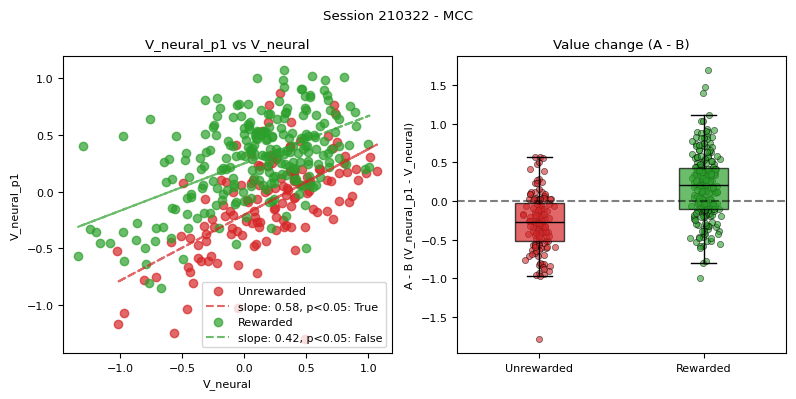

In [8]:
# plot B vs A under 2 conditions of C
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

palette = {'0': 'tab:red', '1': 'tab:green'}

# Left plot: B vs A scatter
for feedback in ['0', '1']:
    mask = data_temp['C'] == int(feedback)
    axs[0].scatter(data_temp.loc[mask, 'B'], data_temp.loc[mask, 'A'], 
               c=palette[feedback], label=f'{"Unrewarded" if feedback == "0" else "Rewarded"}', alpha=0.7)
    # add positive and negative slopes
    z = np.polyfit(data_temp.loc[mask, 'B'], data_temp.loc[mask, 'A'], 1)
    p = np.poly1d(z)
    axs[0].plot(data_temp.loc[mask, 'B'], p(data_temp.loc[mask, 'B']), "--", alpha=0.7, label=f'slope: {z[0]:.2f}, p<0.05: {z[1]<0.05}', color=palette[feedback])
axs[0].set_ylabel('V_neural_p1')
axs[0].set_xlabel('V_neural')
axs[0].legend()
axs[0].set_title('V_neural_p1 vs V_neural')

# Right plot: A-B for 2 conditions (scatter + boxplot)
data_temp['diff'] = data_temp['A'] - data_temp['B']
feedback_values = [0, 1]
feedback_labels = ['Unrewarded', 'Rewarded']

# Boxplot
bp = axs[1].boxplot([data_temp[data_temp['C'] == fb]['diff'].values for fb in feedback_values],
                     positions=feedback_values, widths=0.3, patch_artist=True,
                     boxprops=dict(alpha=0.7), showfliers=False,
                     medianprops=dict(color='black'))

# Color boxes
for patch, feedback in zip(bp['boxes'], feedback_values):
    patch.set_facecolor(palette[str(feedback)])

# Scatter points
for feedback in feedback_values:
    mask = data_temp['C'] == feedback
    y_data = data_temp.loc[mask, 'diff'].values
    x_jitter = np.random.normal(feedback, 0.04, size=len(y_data))
    axs[1].scatter(x_jitter, y_data, alpha=0.6, s=20, c=palette[str(feedback)], edgecolor='black', linewidth=0.5)

axs[1].set_xticks(feedback_values)
axs[1].set_xticklabels(feedback_labels)
axs[1].set_ylabel('A - B (V_neural_p1 - V_neural)')
axs[1].axhline(0, linestyle='--', alpha=0.5, color='black')
axs[1].set_title('Value change (A - B)')

fig.suptitle(f'Session {results_df_temp["session"].values[0]} - {results_df_temp["subregion"].values[0]}')
plt.tight_layout()
plt.show()

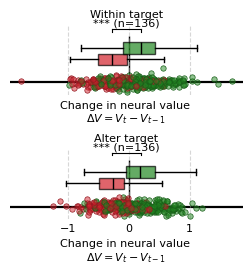

In [9]:
# Create the figure
fig, axs = plt.subplots(2, 1, figsize=(3, 2.5), sharex=True, gridspec_kw={'height_ratios': [1, 1], 'hspace': .8})

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
plot_RL_vs_forage_single_sess_horizontal(axs[0],
                   results_df_temp.loc[results_df_temp['type'] == 'within'], 
                   'feedback', 'dV_neural', paper_format=True)
axs[0].set_title('Within target', fontsize=8)

# Alter target plot
plot_RL_vs_forage_single_sess_horizontal(axs[1], 
                   results_df_temp.loc[results_df_temp['type'] == 'alter'],
                   'feedback', 'dV_neural', paper_format=True)
axs[1].set_title('Alter target', fontsize=8)

# save svg
fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'single_session_ka_21322_mcc.svg'), 
            bbox_inches='tight', dpi=300, transparent=True)

# Extract value-coding hypothesis (in the within target condition)

We use the same tool as in fig 4 to extract the hypothesis (if delta-rule consistent or not), but now only in the within target condition.

In [10]:
# summarize value coding hypothesis per session
session_summary = make_session_summary(res)
session_summary

,monkey,session,subregion,hypothesis
0,ka,010720,MCC,Delta rule (strict)
1,ka,010720,vLPFC,Delta rule (loose)
2,ka,010822,MCC,Delta rule (loose)
3,ka,010822,dLPFC,Other
4,ka,010922,MCC,Other
...,...,...,...,...
197,po,300322,vLPFC,Other
198,po,300421,MCC,Delta rule (loose)
199,po,300421,dLPFC,Feedback
200,po,310822,MCC,Other


## Plot prop sessions per hypothesis and area

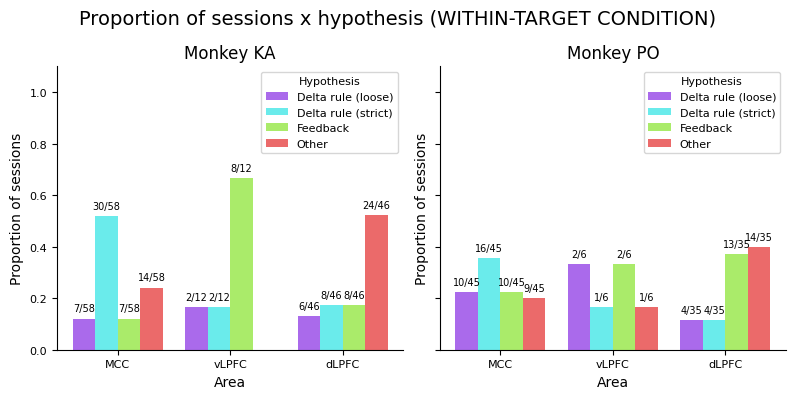

In [11]:
# Get unique monkeys, areas, and hypotheses
monkeys = session_summary['monkey'].unique()
areas = session_summary['subregion'].unique()
hypotheses = sorted(session_summary['hypothesis'].dropna().unique())

# Assign arbitrary but distinct colors to each hypothesis
rng = np.random.default_rng(42)
hues = np.linspace(0, 1, len(hypotheses), endpoint=False)
rng.shuffle(hues)
hypothesis_colors = {
    hyp: mcolors.to_hex(mcolors.hsv_to_rgb((h, 0.7, 0.9)))
    for hyp, h in zip(hypotheses, hues)
}

# Create figure with one subplot per monkey
fig, axs = plt.subplots(1, len(monkeys), figsize=(4 * len(monkeys), 4), sharey=True)
if len(monkeys) == 1:
    axs = [axs]

for i, monkey in enumerate(monkeys):
    ax = axs[i]
    
    # Filter data for this monkey
    monkey_data = session_summary[session_summary['monkey'] == monkey]
    
    # Calculate proportions and counts for each area and hypothesis
    proportions = {}
    counts = {}
    totals = {}
    for area in areas:
        area_data = monkey_data[monkey_data['subregion'] == area]
        total_sessions = len(area_data)
        totals[area] = total_sessions
        
        proportions[area] = {}
        counts[area] = {}
        for hyp in hypotheses:
            hyp_count = len(area_data[area_data['hypothesis'] == hyp])
            counts[area][hyp] = hyp_count
            proportions[area][hyp] = hyp_count / total_sessions if total_sessions > 0 else 0
    
    # Set up bar positions
    x_positions = np.arange(len(areas))
    bar_width = 0.8 / len(hypotheses)
    
    # Plot bars for each hypothesis
    for j, hyp in enumerate(hypotheses):
        positions = x_positions + (j - len(hypotheses)/2 + 0.5) * bar_width
        values = [proportions[area].get(hyp, 0) for area in areas]
        
        color = hypothesis_colors[hyp]
        
        bars = ax.bar(positions, values, bar_width, label=hyp, color=color, alpha=0.8)
        
        # Add text annotations with count/total format
        for k, (pos, val, area) in enumerate(zip(positions, values, areas)):
            count = counts[area].get(hyp, 0)
            total = totals[area]
            if count > 0:  # Only show label if there are sessions
                ax.text(pos, val + 0.02, f'{count}/{total}', 
                       ha='center', va='bottom', fontsize=7, rotation=0)
    
    # Formatting
    ax.set_xlabel('Area', fontsize=10)
    ax.set_ylabel('Proportion of sessions', fontsize=10)
    ax.set_title(f'Monkey {monkey.upper()}', fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(areas)
    ax.set_ylim(0, 1.1)  # Increased to accommodate text labels
    ax.legend(title='Hypothesis', fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('Proportion of sessions x hypothesis (WITHIN-TARGET CONDITION)', fontsize=14)


plt.tight_layout()
plt.show()

# Get dV modulation and hypothesis

In [12]:
results_df_mean = get_session_mean_value(res, session_summary)

## Plot dV(t) vs dV(t+1) for each session, colored by hypothesis

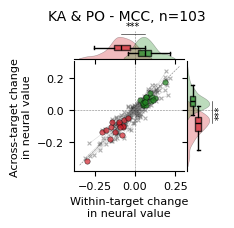

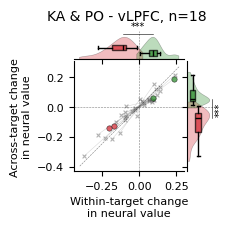

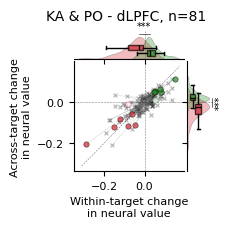

In [13]:
plot_per_monkey = False
for subregion in results_df_mean['subregion'].unique():
    
    data = results_df_mean.loc[(results_df_mean['subregion'] == subregion)]
    fig, ax_main, ax_top, ax_right = create_2d_scatter_with_marginals(data, palette=COLORS, paper_format=True)
    fig.suptitle(f'KA & PO - {subregion}, n={len(np.unique(data.session))}', fontsize=10)

    fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', f'scatter_single_session_KAPO_{subregion}.svg'), bbox_inches='tight', dpi=300, transparent=True)

    if plot_per_monkey:
        for monkey in results_df_mean['monkey'].unique():
            data = results_df_mean.loc[(results_df_mean['subregion'] == subregion) & (results_df_mean['monkey'] == monkey)]
            fig, ax_main, ax_top, ax_right = create_2d_scatter_with_marginals(data, palette=COLORS, paper_format=True)
            fig.suptitle(f'{monkey.capitalize()} - {subregion}, n={len(np.unique(data.session))}', fontsize=10)

            fig.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', f'scatter_single_session_{monkey}_{subregion}.svg'), bbox_inches='tight', dpi=300, transparent=True)


## Print stats

In [14]:
# Extract hypothesis info

stats_df = extract_hypothesis(results_df_mean, detailed=False)

stats_df

,monkey,subregion,hypothesis,count
0,ka,MCC,Foraging,5
1,ka,MCC,Standard RL,0
2,ka,MCC,Inferential RL,0
3,ka,MCC,none,53
4,ka,dLPFC,Foraging,4
5,ka,dLPFC,Standard RL,0
6,ka,dLPFC,Inferential RL,0
7,ka,dLPFC,none,42
8,ka,vLPFC,Foraging,1
9,ka,vLPFC,Standard RL,0


Subregion: vLPFC, Hypothesis: none, Proportion: 88.9% (16/18 sessions)
Subregion: vLPFC, Hypothesis: Foraging, Proportion: 11.1% (2/18 sessions)
Subregion: vLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/18 sessions)
Subregion: vLPFC, Hypothesis: Standard RL, Proportion: 0.0% (0/18 sessions)
Subregion: dLPFC, Hypothesis: none, Proportion: 91.4% (74/81 sessions)
Subregion: dLPFC, Hypothesis: Foraging, Proportion: 7.4% (6/81 sessions)
Subregion: dLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/81 sessions)
Subregion: dLPFC, Hypothesis: Standard RL, Proportion: 1.2% (1/81 sessions)
Subregion: MCC, Hypothesis: none, Proportion: 85.4% (88/103 sessions)
Subregion: MCC, Hypothesis: Foraging, Proportion: 14.6% (15/103 sessions)
Subregion: MCC, Hypothesis: Inferential RL, Proportion: 0.0% (0/103 sessions)
Subregion: MCC, Hypothesis: Standard RL, Proportion: 0.0% (0/103 sessions)
Subregion: vLPFC, Hypothesis: none, Proportion: 91.7% (11/12 sessions)
Subregion: vLPFC, Hypothesis: For

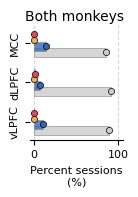

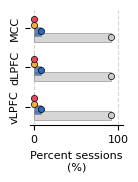

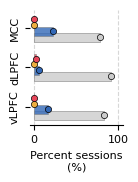

In [15]:
# print stats

fig_bar_both, _, _, _ = print_stats_both(stats_df)
fig_bar_ka, _, _, _ = print_stats_both(stats_df.loc[stats_df['monkey'] == 'ka'])
fig_bar_po, _, _, _ = print_stats_both(stats_df.loc[stats_df['monkey'] == 'po'])

fig_bar_both.suptitle('Both monkeys', fontsize=10)
# save figure
fig_bar_both.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_bars_both.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)
fig_bar_ka.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_bars_ka.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)
fig_bar_po.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'rl_vs_forage', 'RL_forage_bars_po.svg'), format='svg', bbox_inches='tight', dpi=300, transparent=True)


# Plot and print stats across time windows

What we want is to plot the last figure above (print_stats_both) for each time window side by side.

Subregion: vLPFC, Hypothesis: none, Proportion: 72.2% (13/18 sessions)
Subregion: vLPFC, Hypothesis: Foraging, Proportion: 27.8% (5/18 sessions)
Subregion: vLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/18 sessions)
Subregion: vLPFC, Hypothesis: Standard RL, Proportion: 0.0% (0/18 sessions)
Subregion: dLPFC, Hypothesis: none, Proportion: 82.7% (67/81 sessions)
Subregion: dLPFC, Hypothesis: Foraging, Proportion: 17.3% (14/81 sessions)
Subregion: dLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/81 sessions)
Subregion: dLPFC, Hypothesis: Standard RL, Proportion: 0.0% (0/81 sessions)
Subregion: MCC, Hypothesis: none, Proportion: 71.8% (74/103 sessions)
Subregion: MCC, Hypothesis: Foraging, Proportion: 28.2% (29/103 sessions)
Subregion: MCC, Hypothesis: Inferential RL, Proportion: 0.0% (0/103 sessions)
Subregion: MCC, Hypothesis: Standard RL, Proportion: 0.0% (0/103 sessions)


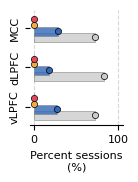

Subregion: vLPFC, Hypothesis: none, Proportion: 88.9% (16/18 sessions)
Subregion: vLPFC, Hypothesis: Foraging, Proportion: 11.1% (2/18 sessions)
Subregion: vLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/18 sessions)
Subregion: vLPFC, Hypothesis: Standard RL, Proportion: 0.0% (0/18 sessions)
Subregion: dLPFC, Hypothesis: none, Proportion: 100.0% (81/81 sessions)
Subregion: dLPFC, Hypothesis: Foraging, Proportion: 0.0% (0/81 sessions)
Subregion: dLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/81 sessions)
Subregion: dLPFC, Hypothesis: Standard RL, Proportion: 0.0% (0/81 sessions)
Subregion: MCC, Hypothesis: none, Proportion: 94.2% (97/103 sessions)
Subregion: MCC, Hypothesis: Foraging, Proportion: 3.9% (4/103 sessions)
Subregion: MCC, Hypothesis: Inferential RL, Proportion: 0.0% (0/103 sessions)
Subregion: MCC, Hypothesis: Standard RL, Proportion: 1.9% (2/103 sessions)


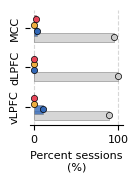

Subregion: vLPFC, Hypothesis: none, Proportion: 55.6% (10/18 sessions)
Subregion: vLPFC, Hypothesis: Foraging, Proportion: 38.9% (7/18 sessions)
Subregion: vLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/18 sessions)
Subregion: vLPFC, Hypothesis: Standard RL, Proportion: 5.6% (1/18 sessions)
Subregion: dLPFC, Hypothesis: none, Proportion: 85.2% (69/81 sessions)
Subregion: dLPFC, Hypothesis: Foraging, Proportion: 12.3% (10/81 sessions)
Subregion: dLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/81 sessions)
Subregion: dLPFC, Hypothesis: Standard RL, Proportion: 2.5% (2/81 sessions)
Subregion: MCC, Hypothesis: none, Proportion: 86.4% (89/103 sessions)
Subregion: MCC, Hypothesis: Foraging, Proportion: 10.7% (11/103 sessions)
Subregion: MCC, Hypothesis: Inferential RL, Proportion: 0.0% (0/103 sessions)
Subregion: MCC, Hypothesis: Standard RL, Proportion: 2.9% (3/103 sessions)


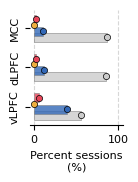

Subregion: vLPFC, Hypothesis: none, Proportion: 88.9% (16/18 sessions)
Subregion: vLPFC, Hypothesis: Foraging, Proportion: 11.1% (2/18 sessions)
Subregion: vLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/18 sessions)
Subregion: vLPFC, Hypothesis: Standard RL, Proportion: 0.0% (0/18 sessions)
Subregion: dLPFC, Hypothesis: none, Proportion: 91.4% (74/81 sessions)
Subregion: dLPFC, Hypothesis: Foraging, Proportion: 7.4% (6/81 sessions)
Subregion: dLPFC, Hypothesis: Inferential RL, Proportion: 0.0% (0/81 sessions)
Subregion: dLPFC, Hypothesis: Standard RL, Proportion: 1.2% (1/81 sessions)
Subregion: MCC, Hypothesis: none, Proportion: 85.4% (88/103 sessions)
Subregion: MCC, Hypothesis: Foraging, Proportion: 14.6% (15/103 sessions)
Subregion: MCC, Hypothesis: Inferential RL, Proportion: 0.0% (0/103 sessions)
Subregion: MCC, Hypothesis: Standard RL, Proportion: 0.0% (0/103 sessions)


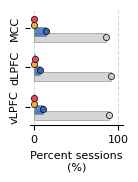

In [17]:
from run_neural_value_across_target import TIMES_OF_INTEREST, make_params
%matplotlib inline

for i, (key, time_window) in enumerate(TIMES_OF_INTEREST.items()):
    params = make_params(key, time_window)  # generate parameters for the current time window
    floc = params['floc']
    time_window_vals = params['time_of_interest']

    # load and process data for this time window
    res = get_data(floc=floc)
    res = merge_alter_values(res) # Merge 'alter' type rows by averaging their values for each trial, so that we only have one

    # summarize value coding hypothesis per session
    session_summary = make_session_summary(res)

    results_df_mean = get_session_mean_value(res, session_summary)
    
    stats_df = extract_hypothesis(results_df_mean, detailed=False)

    fig_bar_both, _, _, _ = print_stats_both(stats_df)
    # legend
    #fig_bar_both.legend(loc='upper right', fontsize=8, title='Hypothesis')
    plt.show()